# 模式识别择时功能演示 (Pattern Timing)

本 Notebook 演示如何从 `timing.pattern_timing` 模块调用扩展后的模式识别功能，包括：
- 基础价格模式 (头肩顶、三角形、楔形、通道)
- 扩展模式 (多重顶/底、双顶/底)
- 技术指标 (动态支撑/阻力位、枢轴点 HH/LL)
- 信号可视化与导出存储


In [27]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# 1.1 项目环境配置
PROJECT_ROOT = Path(os.getcwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

# 导入模式定义模块
from timing.pattern_timing import run_pattern_recognition, save_pattern_results
from core.DataManager import DataProvider

# 设置绘图风格
plt.style.use('seaborn-v0_8')
plt.rcParams['font.sans-serif'] = ['SimHei'] # 解决中文显示
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示


In [28]:
# 2.0 数据准备
dp = DataProvider(base_data_path="D:/DATA")
index_ticker = "000985.CSI"
index_file = "INDEX/STOCK/000985.CSI.xlsx"

print(f"Loading data for {index_ticker}...")
ohlc_df = dp.get_ohlc_data(index_file)

if ohlc_df is not None:
    print(f"Loaded {len(ohlc_df)} entries from {ohlc_df.index.min()} to {ohlc_df.index.max()}")
    print("\nSample Data (Last 5 Rows):")
    display(ohlc_df.tail())
else:
    print("Error: Could not load data.")


Loading data for 000985.CSI...
16:04:29 - [INFO] - Loading OHLC data: D:\DATA\INDEX\STOCK\000985.CSI.xlsx
16:04:29 - [INFO] - Detected standard OHLC header at row 3
Loaded 5152 entries from 2005-01-04 00:00:00 to 2026-03-24 00:00:00

Sample Data (Last 5 Rows):


,open,high,low,close,volume,amount
date,,,,,,
2026-03-18,6137.9591,6174.0189,6081.4279,6169.4205,1.264157e+11,2.008726e+12
2026-03-19,6097.0645,6113.6925,6018.3213,6039.1833,1.321646e+11,2.080306e+12
2026-03-20,6064.6227,6089.1452,5963.4726,5965.8893,1.370734e+11,2.253739e+12
2026-03-23,5863.8839,5905.9172,5692.4722,5723.4126,1.622826e+11,2.397339e+12
2026-03-24,5802.4662,5843.7257,5696.4141,5843.7257,1.380132e+11,2.049422e+12


In [29]:
# 3.0 执行扩展模式识别逻辑
# 调用 pattern_timing.py 中的综合识别函数，窗口大小设为 20 以提高稳定性
print("Executing pattern recognition suite (Extended)...")
final_patterns = run_pattern_recognition(ohlc_df, window=10)

# 合并原始收盘价用于后续绘图 (注意 DataProvider 返回的是小写 close)
plot_df = pd.merge(ohlc_df[['close']], final_patterns, left_index=True, right_index=True)

print(f"\nCompleted recognition. Columns generated: {final_patterns.columns.tolist()}")

# 展示最近 10 次识别出的模式信号分布状况
print("\nRecent pattern signal occurrences:")
display(final_patterns.dropna(how='all', subset=final_patterns.columns.difference(['support', 'resistance'])).tail(50))


Executing pattern recognition suite (Extended)...
16:04:29 - [INFO] - Starting Pattern Recognition...

Completed recognition. Columns generated: ['head_shoulder_pattern', 'multiple_top_bottom_pattern', 'triangle_pattern', 'wedge_pattern', 'channel_pattern', 'double_pattern', 'signal', 'support', 'resistance']

Recent pattern signal occurrences:


,head_shoulder_pattern,multiple_top_bottom_pattern,triangle_pattern,wedge_pattern,channel_pattern,double_pattern,signal,support,resistance
date,,,,,,,,,
2026-01-06,NaN,NaN,NaN,NaN,NaN,NaN,,5646.0361,5855.1160
2026-01-07,NaN,NaN,NaN,NaN,NaN,NaN,,5646.0361,5855.1160
2026-01-08,NaN,NaN,NaN,NaN,NaN,NaN,,5646.0361,5855.1160
2026-01-09,NaN,NaN,NaN,NaN,NaN,NaN,,5646.0361,5855.1160
2026-01-12,NaN,NaN,NaN,NaN,NaN,NaN,,5646.0361,5855.1160
2026-01-13,NaN,NaN,NaN,NaN,NaN,NaN,,5646.0361,5855.1160
2026-01-14,NaN,NaN,NaN,NaN,NaN,NaN,HH,5646.0361,5855.1160
2026-01-15,NaN,NaN,NaN,NaN,NaN,NaN,,5646.0361,5855.1160
2026-01-16,NaN,NaN,NaN,NaN,NaN,NaN,,5646.0361,5855.1160


Total significant pivots found: 121


,open,high,low,close,volume,amount,type,pivot_price
2024-05-20,4427.5608,4452.7781,4426.0896,4444.1350,9.217495e+10,9.707469e+11,Peak,4452.7781
2024-09-18,3680.8572,3695.4011,3645.4741,3684.1618,5.590686e+10,4.697315e+11,Trough,3645.4741
2024-10-08,5252.3338,5252.3338,4803.3249,5037.0114,2.790992e+11,3.377780e+12,Peak,5252.3338
2025-01-13,4433.5019,4497.6611,4430.1570,4472.6020,8.591598e+10,9.534103e+11,Trough,4430.1570
2025-03-18,5058.2318,5072.9336,5041.0928,5060.9371,1.104814e+11,1.514931e+12,Peak,5072.9336
2025-04-09,4346.4400,4499.4711,4252.8192,4486.4734,1.530963e+11,1.684606e+12,Trough,4252.8192
2025-05-14,4828.0030,4888.8270,4815.3455,4864.4848,1.042250e+11,1.296672e+12,Peak,4888.8270
2025-06-23,4731.7492,4801.5331,4731.7380,4794.1406,8.945813e+10,1.113808e+12,Trough,4731.7380
2025-10-09,5907.3329,5967.4257,5892.6974,5952.8519,1.476298e+11,2.612370e+12,Peak,5967.4257
2025-11-24,5603.4937,5633.6529,5557.2015,5608.6852,1.152167e+11,1.694890e+12,Trough,5557.2015


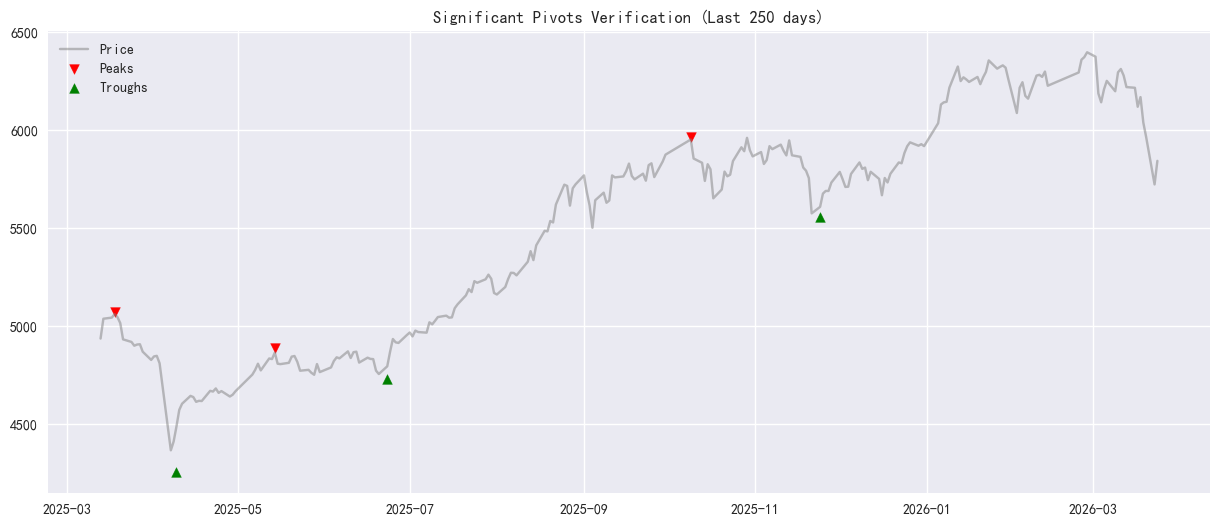

In [30]:
# 3.1 验证极值点识别逻辑 (DEBUG 模式)
from timing.pattern_timing import find_significant_pivots

# 获取极值点
pivots = find_significant_pivots(ohlc_df, window=20)
print(f"Total significant pivots found: {len(pivots)}")
display(pivots.tail(10))

# 可视化极值点以验证其准确性
plt.figure(figsize=(15, 6))
plt.plot(ohlc_df.index[-250:], ohlc_df['close'].iloc[-250:], label='Price', color='gray', alpha=0.5)
p_recent = pivots[pivots.index >= ohlc_df.index[-250]]
plt.scatter(p_recent[p_recent['type']=='Peak'].index, p_recent[p_recent['type']=='Peak']['pivot_price'], color='red', marker='v', label='Peaks')
plt.scatter(p_recent[p_recent['type']=='Trough'].index, p_recent[p_recent['type']=='Trough']['pivot_price'], color='green', marker='^', label='Troughs')
plt.title("Significant Pivots Verification (Last 250 days)")
plt.legend()
plt.show()

In [31]:
# 3.2 诊断：极值点分布与统计
print("极值点类型统计:")
print(pivots['type'].value_counts())

print("\n最近 20 个极值点明细 (确认是否交替出现):")
# 注意：之前代码中虽然计算了 actual_date 但没存入 pivots，这里看 index (信号报出日) 和 pivot_price (当时价格)
display(pivots.tail(20)[['type', 'pivot_price']])

# 检查形态识别的中间变量
from timing.pattern_timing import detect_head_shoulder, detect_double_pattern, detect_triangle_pattern
# 使用 window=20 再次尝试 (对应主流程参数)
hs_20 = detect_head_shoulder(ohlc_df, window=20)
db_20 = detect_double_pattern(ohlc_df, window=20)
tr_20 = detect_triangle_pattern(ohlc_df, window=20)

print(f"\n[Window=20] 形态识别统计:")
print(f"头肩形态识别数: {hs_20.count()}")
print(f"双顶底识别数: {db_20.count()}")
print(f"三角形识别数: {tr_20.count()}")

# 使用 window=5 再次尝试 (观察是否是因为窗口过大导致过滤太严)
hs_5 = detect_head_shoulder(ohlc_df, window=5)
db_5 = detect_double_pattern(ohlc_df, window=5)

print(f"\n[Window=5] 形态识别统计:")
print(f"头肩形态识别数: {hs_5.count()}")
print(f"双顶底识别数: {db_5.count()}")

极值点类型统计:
type
Trough    61
Peak      60
Name: count, dtype: int64

最近 20 个极值点明细 (确认是否交替出现):


,type,pivot_price
2023-02-16,Peak,5219.2390
2023-03-16,Trough,4932.9803
2023-04-18,Peak,5173.4475
2023-06-28,Trough,4752.6443
2023-08-04,Peak,4999.6653
2023-10-23,Trough,4305.1308
2023-11-21,Peak,4658.8793
2024-02-05,Trough,3565.8690
2024-03-21,Peak,4442.9728
2024-04-16,Trough,4124.3279



[Window=20] 形态识别统计:
头肩形态识别数: 9
双顶底识别数: 16
三角形识别数: 41

[Window=5] 形态识别统计:
头肩形态识别数: 49
双顶底识别数: 132


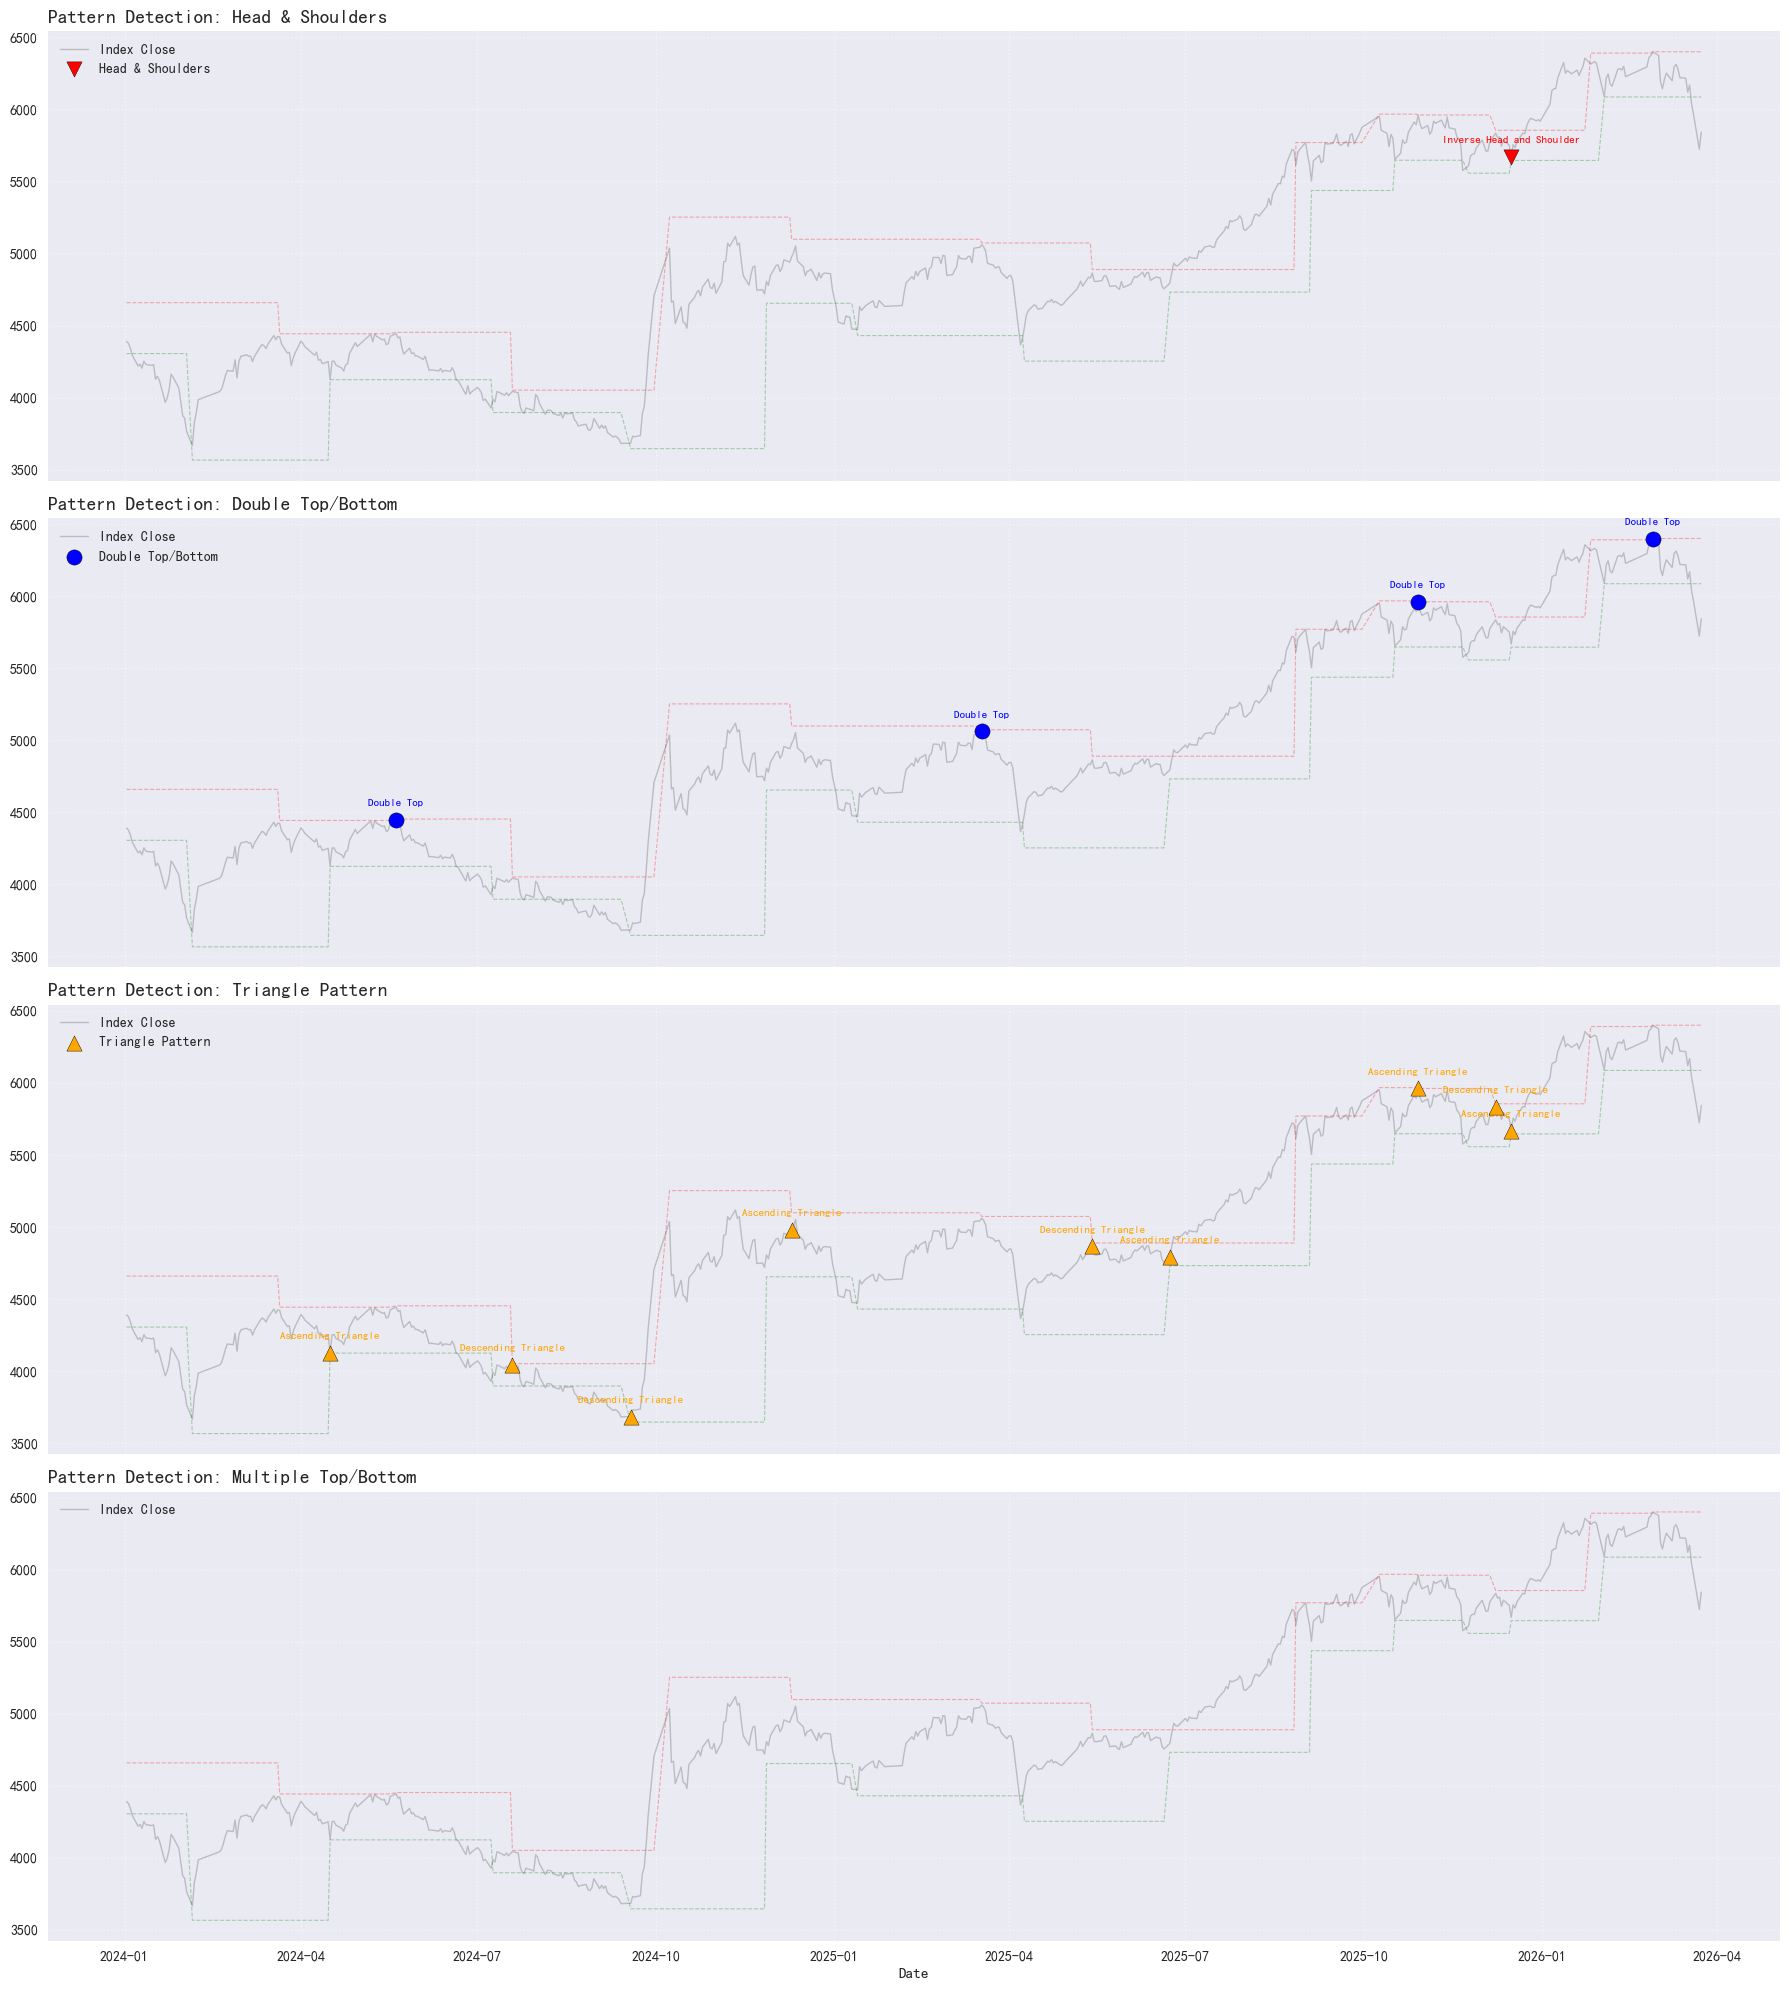

In [ ]:
# 4.0 分开展示所有形态 (每种形态一张独立子图)
plot_start = '2024-01-01'
vis_df = plot_df[plot_start:].copy()

patterns_to_show = [
    ('head_shoulder_pattern', 'Head & Shoulders', 'red', 'v'),
    ('double_pattern', 'Double Top/Bottom', 'blue', 'o'),
    ('triangle_pattern', 'Triangle Pattern', 'orange', '^'),
    ('multiple_top_bottom_pattern', 'Multiple Top/Bottom', 'purple', 'D')
]

fig, axes = plt.subplots(len(patterns_to_show), 1, figsize=(18, 5 * len(patterns_to_show)), sharex=True)

for i, (col, title, color, marker) in enumerate(patterns_to_show):
    ax = axes[i]
    # 绘制背景价格
    ax.plot(vis_df.index, vis_df['close'], color='black', alpha=0.2, linewidth=1, label='Index Close')
    
    # 绘制支撑阻力线
    ax.plot(vis_df.index, vis_df['support'], '--', color='green', alpha=0.3, linewidth=0.8)
    ax.plot(vis_df.index, vis_df['resistance'], '--', color='red', alpha=0.3, linewidth=0.8)
    
    # 标注当前形态
    mask = vis_df[col].notna()
    if mask.any():
        ax.scatter(vis_df.index[mask], vis_df.loc[mask, 'close'], 
                   color=color, marker=marker, s=120, label=title, edgecolors='black', zorder=5)
        
        # 在点旁边标注具体的形态名称
        for idx in vis_df.index[mask]:
            ax.annotate(vis_df.loc[idx, col], (idx, vis_df.loc[idx, 'close']), 
                        textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color=color)
    
    ax.set_title(f"Pattern Detection: {title}", fontsize=14, loc='left')
    ax.legend(loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.5)

plt.xlabel("Date")
plt.tight_layout()
plt.show()

In [33]:
# 5.0 模式识别统计分析 (Signal Frequency)
# 针对每一类模式排除掉 NaN 情况，查看发现的有效信号频率
print("Frequency Analysis of Timing Patterns:")
pattern_cols = final_patterns.columns.difference(['support', 'resistance'])

# 统计该周期内非空值的比例
stats = final_patterns[pattern_cols].count().to_frame(name='Signal Count')
stats['Prevalence (%)'] = (stats['Signal Count'] / len(final_patterns) * 100).round(2)

display(stats.sort_values(by='Signal Count', ascending=False))

# 6.0 导出成果到 Parquet 文件 (Section 7)
# 这将保存为 D:/DATA/TIMING 目录下符合 FactorTester 要求的命名格式
try:
    save_pattern_results(final_patterns, base_filename="000985")
    print("\nCheckpoint: All patterns successfully exported to D:/DATA/TIMING/")
    print("Next step: You can now run a Backtest on these signals in Strategy Tester.")
except Exception as e:
    print(f"Error saving results: {e}")


Frequency Analysis of Timing Patterns:


,Signal Count,Prevalence (%)
signal,5152,100.00
triangle_pattern,83,1.61
double_pattern,43,0.83
head_shoulder_pattern,17,0.33
channel_pattern,0,0.00
multiple_top_bottom_pattern,0,0.00
wedge_pattern,0,0.00


16:04:30 - [INFO] - Saved factor to: D:\DATA\TIMING\head_shoulder_pattern_000985.parquet
16:04:30 - [INFO] - Saved factor to: D:\DATA\TIMING\multiple_top_bottom_pattern_000985.parquet
16:04:30 - [INFO] - Saved factor to: D:\DATA\TIMING\triangle_pattern_000985.parquet
16:04:30 - [INFO] - Saved factor to: D:\DATA\TIMING\wedge_pattern_000985.parquet
16:04:30 - [INFO] - Saved factor to: D:\DATA\TIMING\channel_pattern_000985.parquet
16:04:30 - [INFO] - Saved factor to: D:\DATA\TIMING\double_pattern_000985.parquet
16:04:30 - [INFO] - Saved factor to: D:\DATA\TIMING\signal_000985.parquet

Checkpoint: All patterns successfully exported to D:/DATA/TIMING/
Next step: You can now run a Backtest on these signals in Strategy Tester.
